# 호텔 인포 테이블
* 호텔Id
* 호텔이름
* 호텔등급 
* 총리뷰수
* 평점
* 청결도 "cleanliness":"8.0",
* 서비스 "service":"7.6",
* 편안함 "comfort":"8.2",
* 시설상태 "condition":"7.8",
* 주변환경 "neighbourhood":"8.2"
* 지역 region
* 시도 locality

In [1]:
import json
import pandas as pd

In [2]:
with open("./data/hotels_korea_reviews_text.json" , "r", encoding="utf-8") as file:
    temp = file.read()
    data = json.loads(temp)

In [5]:
# 호텔ID
hotel_id = data[0]['data']['body']['pdpHeader']['hotelId']

1041793024

In [23]:
# 호텔이름
hotel_name = data[0]['data']['body']['propertyDescription']['name']

'상상속의집 (SangSang Hotel)'

In [25]:
# 호텔등급
hotel_grade = data[0]['data']['body']['propertyDescription']['starRating']

3.0

In [27]:
# 총리뷰수
n_reviews = data[0]['data']['body']['reviewContent']['overall']['totalCount']

67

In [28]:
# 평점
avg_rating = data[0]['data']['body']['reviewContent']['overall']['rating']

'7.8'

In [52]:
# 청결도, 서비스, 편안함, 상태, 주변

cleanliness = data[0]['data']['body']['reviewContent']['overall']['ratingAspects']['cleanliness']
service = data[0]['data']['body']['reviewContent']['overall']['ratingAspects']['service']
comfort = data[0]['data']['body']['reviewContent']['overall']['ratingAspects']['comfort']
condition = data[0]['data']['body']['reviewContent']['overall']['ratingAspects']['condition']
neighbourhood = data[0]['data']['body']['reviewContent']['overall']['ratingAspects']['neighbourhood']

In [51]:
# 지역
region = data[0]['data']['body']['propertyDescription']['address']['region']

In [50]:
# 시도
locality = data[0]['data']['body']['propertyDescription']['address']['locality']

In [5]:
hotel_info = {}

# 호텔ID
hotel_id = data[0]['data']['body']['pdpHeader']['hotelId']
# 호텔이름
hotel_name = data[0]['data']['body']['propertyDescription']['name']
# 호텔등급
hotel_grade = data[0]['data']['body']['propertyDescription']['starRating']
# 총리뷰수
n_reviews = data[0]['data']['body']['reviewContent']['overall']['totalCount']
# 평점
avg_rating = data[0]['data']['body']['reviewContent']['overall']['rating']
# 청결도, 서비스, 편안함, 상태, 주변
cleanliness = data[0]['data']['body']['reviewContent']['overall']['ratingAspects']['cleanliness']
service = data[0]['data']['body']['reviewContent']['overall']['ratingAspects']['service']
comfort = data[0]['data']['body']['reviewContent']['overall']['ratingAspects']['comfort']
condition = data[0]['data']['body']['reviewContent']['overall']['ratingAspects']['condition']
neighbourhood = data[0]['data']['body']['reviewContent']['overall']['ratingAspects']['neighbourhood']
# 지역
region = data[0]['data']['body']['propertyDescription']['address']['region']
# 시도
locality = data[0]['data']['body']['propertyDescription']['address']['locality']

hotel_info.setdefault("hotel_id", []).append(hotel_id)
hotel_info.setdefault("hotel_name", []).append(hotel_name)
hotel_info.setdefault("hotel_grade", []).append(hotel_grade)
hotel_info.setdefault("n_reviews", []).append(n_reviews)
hotel_info.setdefault("avg_rating", []).append(avg_rating)
hotel_info.setdefault("cleanliness", []).append(cleanliness)
hotel_info.setdefault("service", []).append(service)
hotel_info.setdefault("comfort", []).append(comfort)
hotel_info.setdefault("condition", []).append(condition)
hotel_info.setdefault("neighbourhood", []).append(neighbourhood)
hotel_info.setdefault("region", []).append(region)
hotel_info.setdefault("locality", []).append(locality)

df = pd.DataFrame(hotel_info)
df

,hotel_id,hotel_name,hotel_grade,n_reviews,avg_rating,cleanliness,service,comfort,condition,neighbourhood,region,locality
0,1041793024,상상속의집 (SangSang Hotel),3.0,67,7.8,8.0,7.6,8.2,7.8,8.2,경상남도,거제시


In [6]:
hotel_info

{'hotel_id': [1041793024],
 'hotel_name': ['상상속의집 (SangSang Hotel)'],
 'hotel_grade': [3.0],
 'n_reviews': [67],
 'avg_rating': ['7.8'],
 'cleanliness': ['8.0'],
 'service': ['7.6'],
 'comfort': ['8.2'],
 'condition': ['7.8'],
 'neighbourhood': ['8.2'],
 'region': ['경상남도'],
 'locality': ['거제시']}

In [ ]:
hotel_info = {}
for idx, hotel in enumerate(data):
    print(f'{idx}/{len(data)} 페이지 데이터 추출중', end="\r")
    # 반복문 하에, data[0] 에서 hotel로 변경
    # 처음에는 .get() 을 쓰지말고, 문제가 되는 요소를 직접 확인해가며 모두 체크 후 get 함수 적용하기
    # 호텔ID
    hotel_id = hotel['data']['body']['pdpHeader']['hotelId']
    # 호텔이름
    hotel_name = hotel['data']['body']['propertyDescription']['name']
    # 호텔등급
    hotel_grade = hotel['data']['body']['propertyDescription']['starRating']
    # 총리뷰수
    n_reviews = hotel['data']['body']['reviewContent']['overall']['totalCount']
    # 평점
    avg_rating = hotel['data']['body']['reviewContent']['overall']['rating']
    # 청결도, 서비스, 편안함, 상태, 주변
    cleanliness = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('cleanliness', 0.0)
    service = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('service', 0.0)
    comfort = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('comfort', 0.0)
    condition = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('condition', 0.0)
    neighbourhood = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('neighbourhood', 0.0)
    # 시도
    locality = hotel['data']['body']['propertyDescription']['address']['locality']
    # 지역
    region = hotel['data']['body']['propertyDescription']['address'].get('region', locality)
    
    hotel_info.setdefault("hotel_id", []).append(hotel_id)
    hotel_info.setdefault("hotel_name", []).append(hotel_name)
    hotel_info.setdefault("hotel_grade", []).append(hotel_grade)
    hotel_info.setdefault("n_reviews", []).append(n_reviews)
    hotel_info.setdefault("avg_rating", []).append(avg_rating)
    hotel_info.setdefault("cleanliness", []).append(cleanliness)
    hotel_info.setdefault("service", []).append(service)
    hotel_info.setdefault("comfort", []).append(comfort)
    hotel_info.setdefault("condition", []).append(condition)
    hotel_info.setdefault("neighbourhood", []).append(neighbourhood)
    hotel_info.setdefault("region", []).append(region)
    hotel_info.setdefault("locality", []).append(locality)
    
hotel_info_df = pd.DataFrame(hotel_info)
hotel_info_df

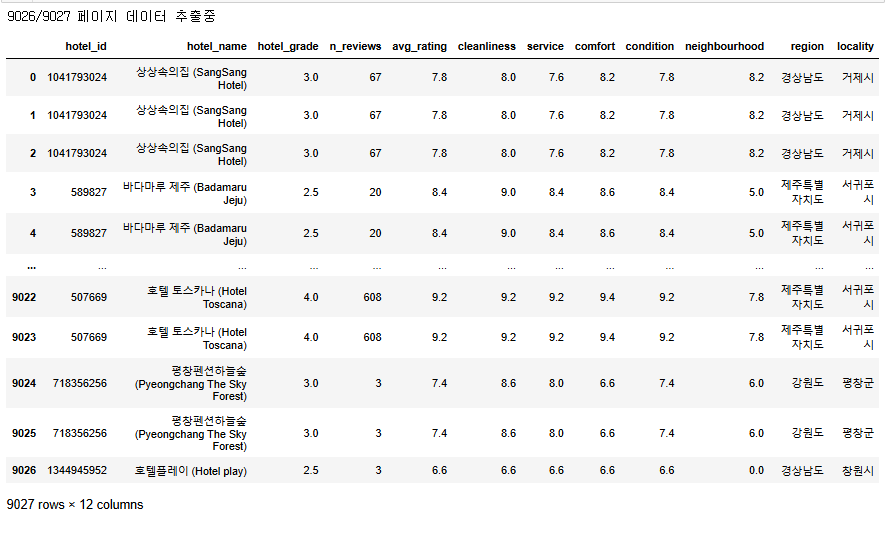

# 반복문으로 평점부분 자동 추출하기

In [ ]:
# 총리뷰수
n_reviews = hotel['data']['body']['reviewContent']['overall']['totalCount']
# 평점
avg_rating = hotel['data']['body']['reviewContent']['overall']['rating']
# 청결도, 서비스, 편안함, 상태, 주변
cleanliness = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('cleanliness', 0.0)
service = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('service', 0.0)
comfort = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('comfort', 0.0)
condition = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('condition', 0.0)

neighbourhood = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('neighbourhood', 0.0)

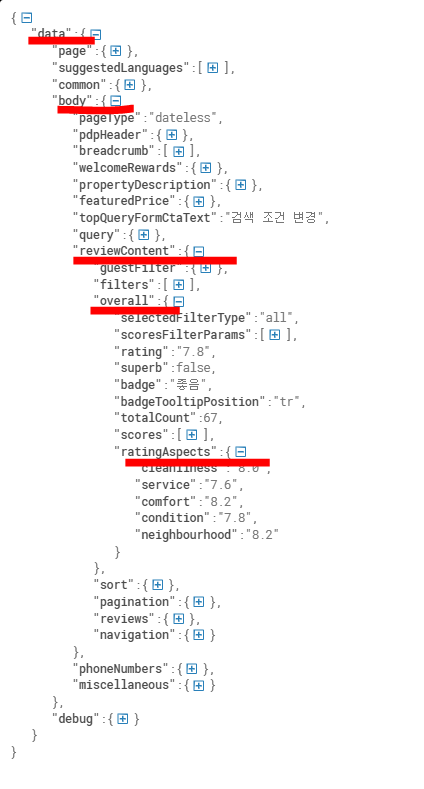

In [119]:
# 빈딕셔너리 주기
temp = {}
# data 딕셔너리 100개 리스트에서 언패킹 하기 (with 인덱스 번호)
# 반복문1
for idx, hotel in enumerate(data[:100]):
#     print(f'{idx}/{len(data)} 페이지 데이터 추출중', end="\r")
    # 반복문 하에서 언패킹된 딕셔너리를 overall 변수에 할당
    overall = hotel['data']['body']['reviewContent']['overall']\
    # overall 딕셔너리 반복문 : overall의 key만 추출
    # 반복문2
    for key in overall:
        # 조건문1: totalCount, rating 키에 해당한다면
        if key in ['totalCount', 'rating']:
            # 조건문1_append: temp{}에  overall의 key(totalCount, rating)와 key의 value값 []로삽입
            temp.setdefault(key, []).append(overall[key])
        # 조건문2: ratingAspects 키에 해당한다면
        elif key == "ratingAspects":
            # 반복문3
            # 아래와 동일한 의미의 코드
            # for ra_key in overall["ratingAspects"].keys():
                # temp.setdefault(ra_key, []).append(overall["ratingAspects"][ra_key])
            for ra_key in overall[key].keys():
                # 조건문2_append: temp{}에  overall의 key(ratingAspects)와 key의 value값 []로삽입
                # ratingAspects에는 하위 딕셔너리인 cleanliness, service, comfort, condition, neighbourhood 가 존재하므로
                # 반복문을 중첩해서 사용한 것.
                temp.setdefault(ra_key, []).append(overall[key][ra_key])
#                 print(overall[key].keys())
print()
print(temp, len(temp))
print()
print(len(temp))


{'rating': ['7.8', '7.8', '7.8', '8.4', '8.4', '8.2', '8.2', '6.2', '6.2', '8.0', '8.0', '8.0', '8.0', '2.0', '2.0', '9.4', '9.4', '8.6', '8.6', '8.6', '8.6', '8.6', '8.6', '8.6', '8.6', '8.6', '8.6', '8.6', '8.0', '8.0', '8.4', '8.4', '7.2', '7.2', '8.4', '8.4', '8.4', '8.4', '8.4', '8.4', '8.4', '8.4', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '9.0', '7.0', '7.0', '9.0', '9.0', '8.6', '8.6', '8.6', '8.6', '8.6', '8.6', '2.0', '2.0', '2.6', '2.6', '7.0', '7.0', '7.6', '7.6', '7.6', '7.8', '7.8', '7.8', '7.8', '7.8', '7.8', '8.2', '8.2', '8.2', '8.2', '8.2', '2.0', '2.0', '9.6', '9.6', '7.0', '7.0', '8.0', '8.0', '8.0', '8.8'], 'totalCount': [67, 67, 67, 20, 20, 31, 31, 10, 10, 1, 1, 1, 1, 2, 2, 3, 3, 454, 454, 454, 454, 454, 454, 454, 454, 454, 454, 454, 1, 1, 21, 21, 8, 8, 331, 331, 331, 331, 331, 331, 331, 331, 803, 803, 803, 803, 803, 803, 803, 803, 803, 803, 803, 803, 803, 803, 803, 803, 803, 803, 13, 13

In [118]:
temp = {}
for idx, hotel in enumerate(data[:4]):
#     print(f'{idx}/{len(data)} 페이지 데이터 추출중', end="\r")
    overall = hotel['data']['body']['reviewContent']['overall']
    for key in overall:
        if key in ['totalCount', 'rating']:
            temp.setdefault(key, []).append(overall[key])
        elif key == "ratingAspects":
#             print(len(overall[key].keys()))
            for ra_key in overall[key].keys():
                temp.setdefault(ra_key, []).append(overall[key][ra_key])
#                 print(overall[key].keys())
print(temp, len(temp))

{'rating': ['7.8', '7.8', '7.8', '8.4'], 'totalCount': [67, 67, 67, 20], 'cleanliness': ['8.0', '8.0', '8.0', '9.0'], 'service': ['7.6', '7.6', '7.6', '8.4'], 'comfort': ['8.2', '8.2', '8.2', '8.6'], 'condition': ['7.8', '7.8', '7.8', '8.4'], 'neighbourhood': ['8.2', '8.2', '8.2', '5.0']} 7


In [23]:
for key, value in hotel_info.items():
    print(f"{key}, {len(value)}")

hotel_id, 9027
hotel_name, 9027
hotel_grade, 9027
n_reviews, 9027
avg_rating, 9027
cleanliness, 9027
service, 9027
comfort, 9027
condition, 9027
neighbourhood, 9027
region, 9027
locality, 9027


In [47]:
for key in ju:
    print(key)
    

selectedFilterType
scoresFilterParams
rating
superb
badge
badgeTooltipPosition
totalCount
scores
ratingAspects


In [ ]:
########### 무조건 반복문으로 돌리는 게 능사가 아니다... ###########
########### 오류를 찾기가 쉽지 않다.###########
########### 또한 추후에 코드를 유지보수할 때도 직관적인 코드가 이해하기 편하며 코드 동작 시간도 조금 더 짧다###########


hotel_info = {}
for idx, hotel in enumerate(data):
    print(f'{idx}/{len(data)} 페이지 데이터 추출중', end="\r")
    # 반복문 하에, data[0] 에서 hotel로 변경
    # 처음에는 .get() 을 쓰지말고, 문제가 되는 요소를 직접 확인해가며 모두 체크 후 get 함수 적용하기
    # 호텔ID
    hotel_id = hotel['data']['body']['pdpHeader']['hotelId']
    # 호텔이름
    hotel_name = hotel['data']['body']['propertyDescription']['name']
    # 호텔등급
    hotel_grade = hotel['data']['body']['propertyDescription']['starRating']
    # 총리뷰수
    overall = hotel['data']['body']['reviewContent']['overall']
    for key in overall:
        if key in ['totalCount', 'rating']:
            hotel_info.setdefault(key, []).append(overall[key])
        elif key == "ratingAspects":
            ra_keys = ['cleanliness', 'service', 'comfort', 'condition', 'neighbourhood']
            for ra_key in ra_keys:
                hotel_info.setdefault(ra_key, []).append(overall[key].get(ra_key, 0.0))    
    # 시도
    locality = hotel['data']['body']['propertyDescription']['address']['locality']
    # 지역
    region = hotel['data']['body']['propertyDescription']['address'].get('region', locality)
    
    hotel_info.setdefault("hotel_id", []).append(hotel_id)
    hotel_info.setdefault("hotel_name", []).append(hotel_name)
    hotel_info.setdefault("hotel_grade", []).append(hotel_grade)
    hotel_info.setdefault("region", []).append(region)
    hotel_info.setdefault("locality", []).append(locality)
    
hotel_info_df = pd.DataFrame(hotel_info)
hotel_info_df

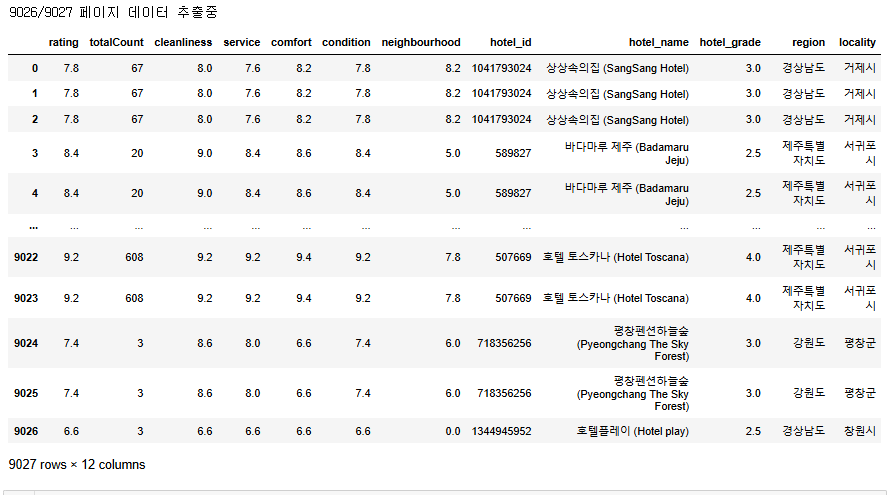

In [62]:
data[9]['data']['body']['reviewContent']['overall']['ratingAspects']

{'cleanliness': '10.0', 'service': '10.0', 'condition': '10.0'}

In [65]:
data[60]['data']['body']['propertyDescription']['address']

{'countryName': '한국',
 'locality': '서울특별시',
 'postalCode': '1168',
 'streetAddress': '강북구 솔매로 62-3',
 'countryAlpha3Code': 'KOR'}

# 호텔 리뷰 데이터 수집하기

* 호텔Id
* 고객id "itineraryId"
* 여행타입 "Triptype"
* 평점 "rating"
* 리뷰 text "description"

In [95]:
# 호텔ID
hotel_id = data[0]['data']['body']['pdpHeader']['hotelId']

In [71]:
hotel_id

1041793024

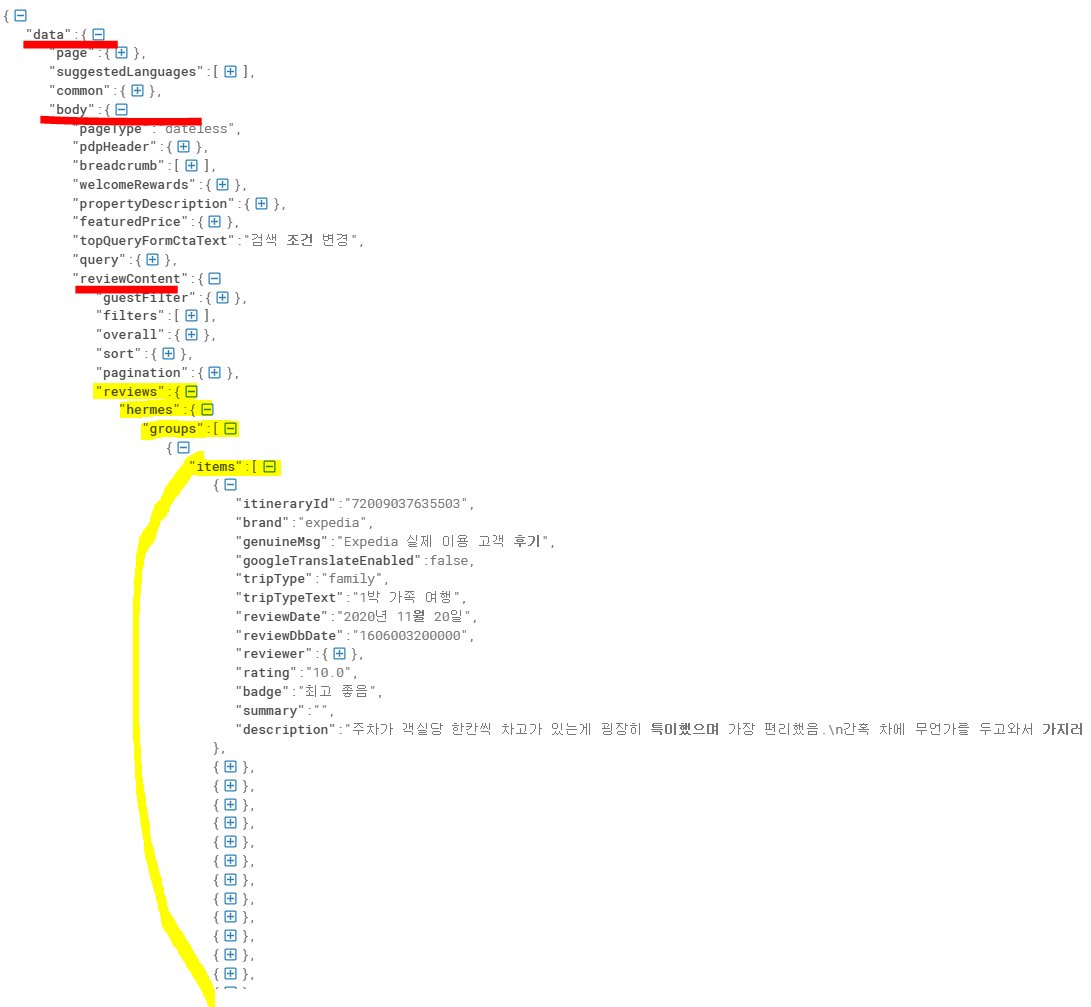

In [83]:
# 고객 리뷰
reviews = data[0]['data']['body']['reviewContent']['reviews']['hermes']['groups'][0]['items']

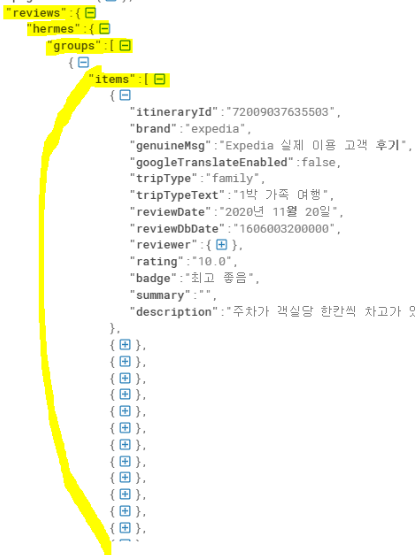

In [84]:
reviews[0]

{'itineraryId': '72009037635503',
 'brand': 'expedia',
 'genuineMsg': 'Expedia 실제 이용 고객 후기',
 'googleTranslateEnabled': False,
 'tripType': 'family',
 'tripTypeText': '1박 가족 여행',
 'reviewDate': '2020년 11월 20일',
 'reviewDbDate': '1606003200000',
 'reviewer': {'name': '나미', 'locality': 'kr', 'locale': 'ko_KR'},
 'rating': '10.0',
 'badge': '최고 좋음',
 'summary': '',
 'description': '주차가 객실당 한칸씩 차고가 있는게 굉장히 특이했으며 가장 편리했음.\n간혹 차에 무언가를 두고와서 가지러 가는 경험을 하는데 리조트나 다른 펜션이었다면 주차장까지 내려가는 번거로움이 있었겠지만 이 호텔에서는 객실 바로밑에 주차장이 있어서 주차장이 가장편리 하였다.\n하지만 방음 수준은 최악'}

In [86]:
reviews[0].keys()

dict_keys(['itineraryId', 'brand', 'genuineMsg', 'googleTranslateEnabled', 'tripType', 'tripTypeText', 'reviewDate', 'reviewDbDate', 'reviewer', 'rating', 'badge', 'summary', 'description'])

In [87]:
# 리뷰일
reviewDate = reviews[0]['reviewDate']
reviewDate

'2020년 11월 20일'

In [88]:
# 고객ID
itineraryId = reviews[0]['itineraryId']
itineraryId

'72009037635503'

In [89]:
# 여행타입
tripType = reviews[0]['tripType']
tripType

'family'

In [90]:
# 평점
rating = reviews[0]['rating']
rating

'10.0'

In [91]:
# 리뷰 text
description = reviews[0]['description']
description

'주차가 객실당 한칸씩 차고가 있는게 굉장히 특이했으며 가장 편리했음.\n간혹 차에 무언가를 두고와서 가지러 가는 경험을 하는데 리조트나 다른 펜션이었다면 주차장까지 내려가는 번거로움이 있었겠지만 이 호텔에서는 객실 바로밑에 주차장이 있어서 주차장이 가장편리 하였다.\n하지만 방음 수준은 최악'

In [92]:
reviews[0].keys()

dict_keys(['itineraryId', 'brand', 'genuineMsg', 'googleTranslateEnabled', 'tripType', 'tripTypeText', 'reviewDate', 'reviewDbDate', 'reviewer', 'rating', 'badge', 'summary', 'description'])

In [100]:
key_list = ['reviewDate', 'itineraryId', 'tripType', 'rating', 'description']
key_list

['reviewDate', 'itineraryId', 'tripType', 'rating', 'description']

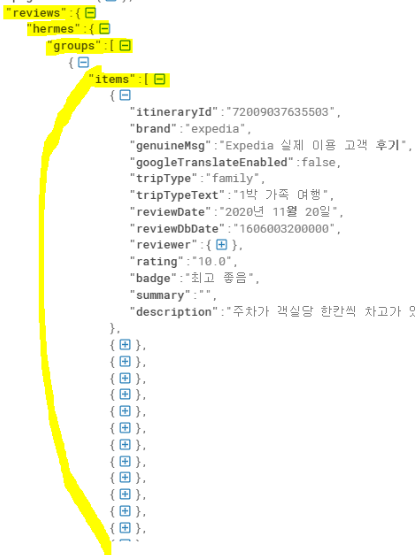

In [96]:
reviewDate = reviews['reviewDate']
itineraryId = reviews['itineraryId']
tripType = reviews['tripType']
rating = reviews['rating']
description = reviews['description']

TypeError: list indices must be integers or slices, not str

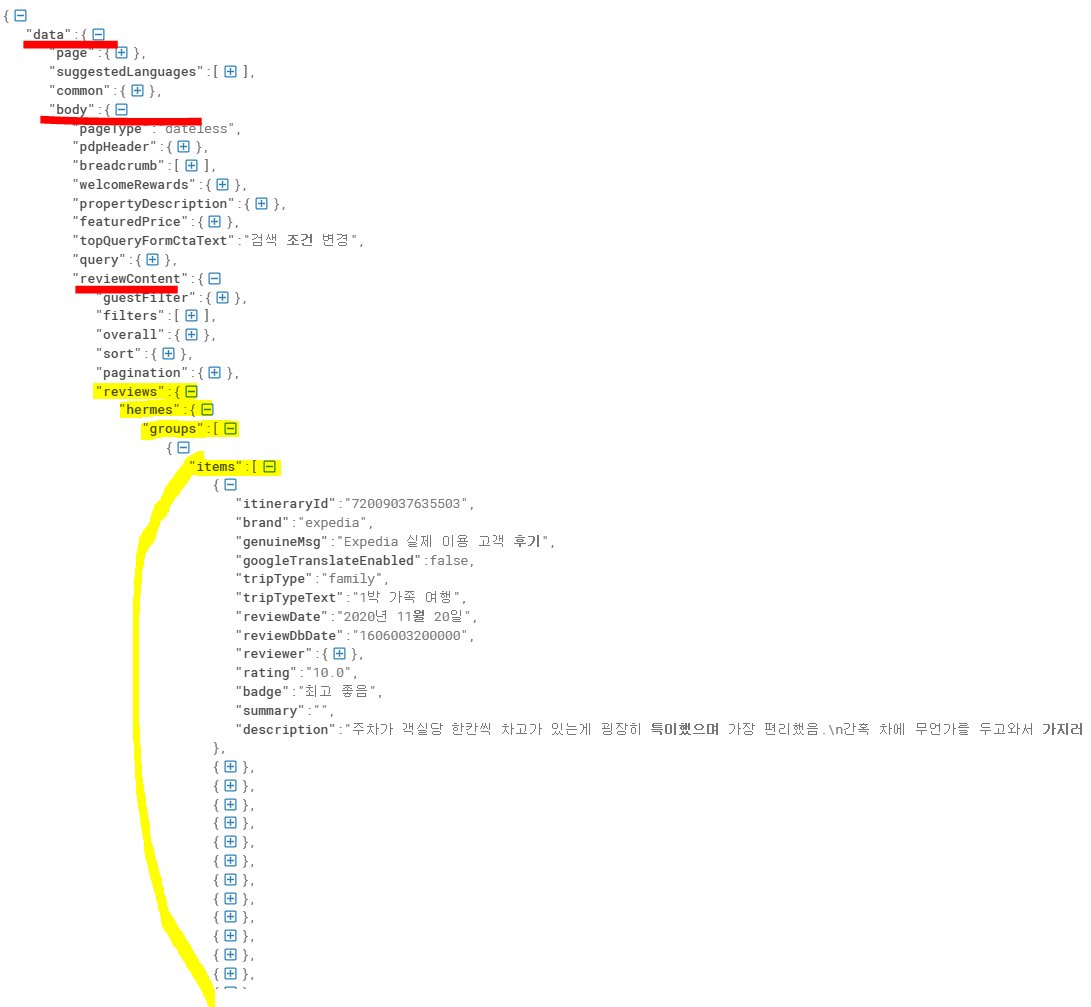

In [99]:
# 데이터 '한 페이지'에(reviews = data[0]···[items]) 있는 리뷰들을 모아서 처리해보는 반복문
# 한 페이지이지만, item이 여러 개 있음을 위의 이미지를 통해 알 수 있다.

key_list = ['reviewDate', 'itineraryId', 'tripType', 'rating', 'description']
all_reviews = {}
for key in key_list:
    for review in reviews:
        all_reviews.setdefault(key, []).append(review[key])

print(all_reviews)

{'reviewDate': ['2020년 11월 20일', '2020년 11월 14일', '2020년 8월 11일', '2020년 8월 10일', '2020년 8월 7일', '2019년 9월 12일', '2020년 7월 15일', '2020년 6월 26일', '2020년 4월 17일', '2020년 2월 21일', '2020년 2월 7일', '2020년 1월 12일', '2019년 12월 20일', '2020년 1월 1일', '2019년 12월 27일', '2019년 12월 20일', '2019년 12월 8일', '2019년 12월 6일', '2019년 12월 4일', '2019년 11월 29일', '2019년 11월 28일', '2019년 10월 3일', '2019년 10월 4일', '2019년 9월 17일', '2019년 9월 7일', '2019년 8월 22일', '2019년 3월 1일', '2019년 8월 8일', '2019년 8월 2일', '2019년 6월 5일', '2019년 5월 18일', '2019년 4월 30일', '2019년 4월 6일', '2019년 3월 31일', '2019년 3월 8일', '2019년 3월 2일', '2019년 2월 18일', '2019년 2월 17일', '2019년 2월 16일', '2019년 2월 9일', '2019년 1월 19일', '2018년 12월 14일'], 'itineraryId': ['72009037635503', '9202656047317', '9196559102828', '9201554317978', '9196473456283', '71000309099267', '9201194045923', '9196050465566', '9195718125010', '9206508579578', '9211413842441', '9211166387771', '9205537092506', '9210621688359', '9205734195501', '9210795416763', '9205554325789', '9210580

### 전체 호텔 리뷰 테이블

In [ ]:
all_reviews = {}
key_list = ['reviewDate', 'itineraryId', 'tripType', 'rating', 'description']

for idx, hotel in enumerate(data):
#     print(f'{idx}/{len(data)} 페이지 데이터 추출중', end="\r")
    hotel_id = hotel['data']['body']['pdpHeader']['hotelId']
    try:
        reviews = hotel['data']['body']['reviewContent']['reviews']['hermes']['groups'][0]['items']
    except Exception as e:
        print(e)
        print(f"{idx}페이지에 수집할 리뷰가 없습니다", end = "\n\n")
    for key in key_list:
        for review in reviews:
            all_reviews.setdefault(key, []).append(review[key])
all_reviews_df = pd.DataFrame(all_reviews)
all_reviews_df

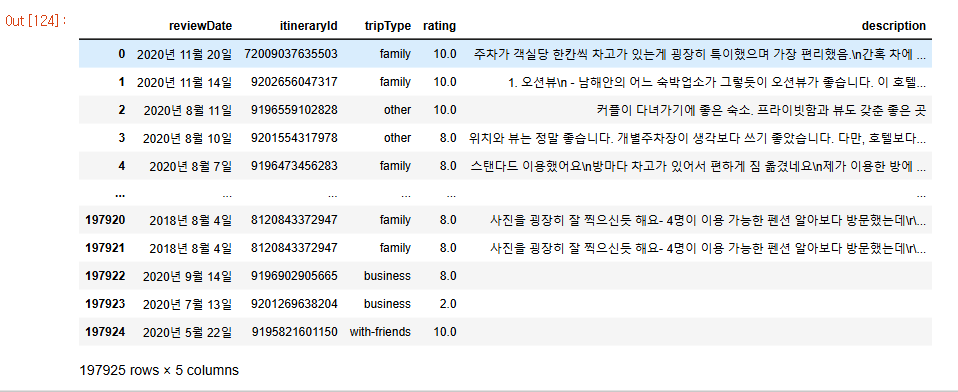

In [121]:
data[2]['data']['body']['reviewContent']['reviews']['hermes']

{'groups': [], 'helpfulReviewsAvailable': False}

#### 호텔 ID를 넣어줄 수 있는 방법

In [ ]:
all_reviews_list = []
key_list = ['reviewDate', 'itineraryId', 'tripType', 'rating', 'description']

for idx, hotel in enumerate(data):
    print(f'{idx}/{len(data)} 페이지 데이터 추출중', end="\r")
    hotel_id = hotel['data']['body']['pdpHeader']['hotelId']
    try:
        reviews = hotel['data']['body']['reviewContent']['reviews']['hermes']['groups'][0]['items']
    except Exception as e:
        print(e)
        print(f"{idx}페이지에 수집할 리뷰가 없습니다", end = "\n\n")
    all_reviews = {}
    all_reviews['hotel_id'] = hotel_id
    for key in key_list:
        for review in reviews:
            all_reviews.setdefault(key, []).append(review[key])
    all_reviews_df = pd.DataFrame(all_reviews)
    all_reviews_list.append(all_reviews_df)
all_reviews_list[0]         

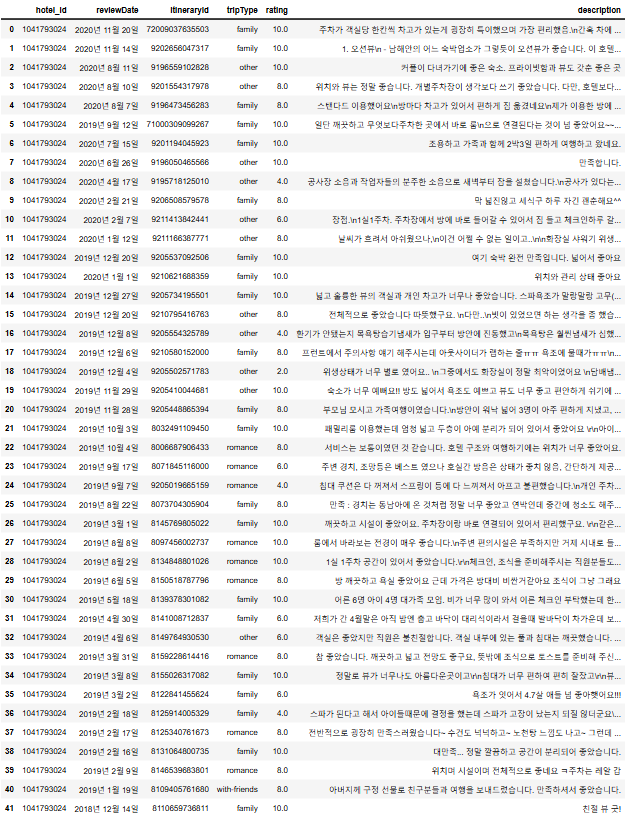

# hotel_info 수집과 review 수집 같이하기

In [ ]:
hotel_info = {}
all_reviews_list = []
    #############################################################################
    # 호텔 인포 수집 부분
    #############################################################################
for idx, hotel in enumerate(data):
    print(f'{idx}/{len(data)} 페이지 데이터 추출중', end="\r")
    # 호텔ID
    hotel_id = hotel['data']['body']['pdpHeader']['hotelId']
    # 호텔이름
    hotel_name = hotel['data']['body']['propertyDescription']['name']
    # 호텔등급
    hotel_grade = hotel['data']['body']['propertyDescription']['starRating']
    # 총리뷰수
    n_reviews = hotel['data']['body']['reviewContent']['overall']['totalCount']
    # 평점
    avg_rating = hotel['data']['body']['reviewContent']['overall']['rating']
    # 청결도, 서비스, 편안함, 상태, 주변
    cleanliness = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('cleanliness', 0.0)
    service = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('service', 0.0)
    comfort = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('comfort', 0.0)
    condition = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('condition', 0.0)
    neighbourhood = hotel['data']['body']['reviewContent']['overall']['ratingAspects'].get('neighbourhood', 0.0)
    # 시도
    locality = hotel['data']['body']['propertyDescription']['address']['locality']
    # 지역
    region = hotel['data']['body']['propertyDescription']['address'].get('region', locality)
    
    hotel_info.setdefault("hotel_id", []).append(hotel_id)
    hotel_info.setdefault("hotel_name", []).append(hotel_name)
    hotel_info.setdefault("hotel_grade", []).append(hotel_grade)
    hotel_info.setdefault("n_reviews", []).append(n_reviews)
    hotel_info.setdefault("avg_rating", []).append(avg_rating)
    hotel_info.setdefault("cleanliness", []).append(cleanliness)
    hotel_info.setdefault("service", []).append(service)
    hotel_info.setdefault("comfort", []).append(comfort)
    hotel_info.setdefault("condition", []).append(condition)
    hotel_info.setdefault("neighbourhood", []).append(neighbourhood)
    hotel_info.setdefault("region", []).append(region)
    hotel_info.setdefault("locality", []).append(locality)
    
    #############################################################################
    # 호텔 리뷰 수집 부분
    #############################################################################
    try:
        reviews = hotel['data']['body']['reviewContent']['reviews']['hermes']['groups'][0]['items']
    except Exception as e:
        print(e)
        print(f"{idx}페이지에 수집할 리뷰가 없습니다", end = "\n\n")
    key_list = ['reviewDate', 'itineraryId', 'tripType', 'rating', 'description']
    all_reviews = {}
    all_reviews['hotel_id'] = hotel_id
    for key in key_list:
        for review in reviews:
            all_reviews.setdefault(key, []).append(review[key])
    all_reviews_df = pd.DataFrame(all_reviews)
    all_reviews_list.append(all_reviews_df)         
    
hotel_info_df = pd.DataFrame(hotel_info)
all_reviews_df= pd.concat(all_reviews_list)

In [108]:
hotel_info_df

,hotel_id,hotel_name,hotel_grade,n_reviews,avg_rating,cleanliness,service,comfort,condition,neighbourhood,region,locality
0,1041793024,상상속의집 (SangSang Hotel),3.0,67,7.8,8.0,7.6,8.2,7.8,8.2,경상남도,거제시
1,1041793024,상상속의집 (SangSang Hotel),3.0,67,7.8,8.0,7.6,8.2,7.8,8.2,경상남도,거제시
2,1041793024,상상속의집 (SangSang Hotel),3.0,67,7.8,8.0,7.6,8.2,7.8,8.2,경상남도,거제시
3,589827,바다마루 제주 (Badamaru Jeju),2.5,20,8.4,9.0,8.4,8.6,8.4,5.0,제주특별자치도,서귀포시
4,589827,바다마루 제주 (Badamaru Jeju),2.5,20,8.4,9.0,8.4,8.6,8.4,5.0,제주특별자치도,서귀포시
...,...,...,...,...,...,...,...,...,...,...,...,...
9022,507669,호텔 토스카나 (Hotel Toscana),4.0,608,9.2,9.2,9.2,9.4,9.2,7.8,제주특별자치도,서귀포시
9023,507669,호텔 토스카나 (Hotel Toscana),4.0,608,9.2,9.2,9.2,9.4,9.2,7.8,제주특별자치도,서귀포시
9024,718356256,평창펜션하늘숲 (Pyeongchang The Sky Forest),3.0,3,7.4,8.6,8.0,6.6,7.4,6.0,강원도,평창군
9025,718356256,평창펜션하늘숲 (Pyeongchang The Sky Forest),3.0,3,7.4,8.6,8.0,6.6,7.4,6.0,강원도,평창군


In [109]:
all_reviews_df

,hotel_id,reviewDate,itineraryId,tripType,rating,description
0,1041793024,2020년 11월 20일,72009037635503,family,10.0,주차가 객실당 한칸씩 차고가 있는게 굉장히 특이했으며 가장 편리했음.\n간혹 차에 ...
1,1041793024,2020년 11월 14일,9202656047317,family,10.0,1. 오션뷰\n - 남해안의 어느 숙박업소가 그렇듯이 오션뷰가 좋습니다. 이 호텔...
2,1041793024,2020년 8월 11일,9196559102828,other,10.0,커플이 다녀가기에 좋은 숙소. 프라이빗함과 뷰도 갖춘 좋은 곳
3,1041793024,2020년 8월 10일,9201554317978,other,8.0,"위치와 뷰는 정말 좋습니다. 개별주차장이 생각보다 쓰기 좋았습니다. 다만, 호텔보다..."
4,1041793024,2020년 8월 7일,9196473456283,family,8.0,스탠다드 이용했어요\n방마다 차고가 있어서 편하게 짐 옮겼네요\n제가 이용한 방에 ...
...,...,...,...,...,...,...
0,718356256,2018년 8월 4일,8120843372947,family,8.0,사진을 굉장히 잘 찍으신듯 해요- 4명이 이용 가능한 펜션 알아보다 방문했는데\r\...
0,718356256,2018년 8월 4일,8120843372947,family,8.0,사진을 굉장히 잘 찍으신듯 해요- 4명이 이용 가능한 펜션 알아보다 방문했는데\r\...
0,1344945952,2020년 9월 14일,9196902905665,business,8.0,
1,1344945952,2020년 7월 13일,9201269638204,business,2.0,


In [112]:
# reset_index(drop=True): 인덱스를 0부터 순차적 인덱스로 재설정하는 명령어
all_reviews_df1 = all_reviews_df.reset_index(drop=True)

In [113]:
all_reviews_df1

,hotel_id,reviewDate,itineraryId,tripType,rating,description
0,1041793024,2020년 11월 20일,72009037635503,family,10.0,주차가 객실당 한칸씩 차고가 있는게 굉장히 특이했으며 가장 편리했음.\n간혹 차에 ...
1,1041793024,2020년 11월 14일,9202656047317,family,10.0,1. 오션뷰\n - 남해안의 어느 숙박업소가 그렇듯이 오션뷰가 좋습니다. 이 호텔...
2,1041793024,2020년 8월 11일,9196559102828,other,10.0,커플이 다녀가기에 좋은 숙소. 프라이빗함과 뷰도 갖춘 좋은 곳
3,1041793024,2020년 8월 10일,9201554317978,other,8.0,"위치와 뷰는 정말 좋습니다. 개별주차장이 생각보다 쓰기 좋았습니다. 다만, 호텔보다..."
4,1041793024,2020년 8월 7일,9196473456283,family,8.0,스탠다드 이용했어요\n방마다 차고가 있어서 편하게 짐 옮겼네요\n제가 이용한 방에 ...
...,...,...,...,...,...,...
197920,718356256,2018년 8월 4일,8120843372947,family,8.0,사진을 굉장히 잘 찍으신듯 해요- 4명이 이용 가능한 펜션 알아보다 방문했는데\r\...
197921,718356256,2018년 8월 4일,8120843372947,family,8.0,사진을 굉장히 잘 찍으신듯 해요- 4명이 이용 가능한 펜션 알아보다 방문했는데\r\...
197922,1344945952,2020년 9월 14일,9196902905665,business,8.0,
197923,1344945952,2020년 7월 13일,9201269638204,business,2.0,


# 복습 포인트

* 디버깅 하는 과정 (모든 페이지가 잘 돌아갈 수 있게 하는 게 1차 목표)
* 일단, **데이터 추출**이 되어야 한다.
* 반복문이 안 되면, 일일이 변수에 할당해서라도 추출을 해보자.

# CSV, 엑셀로 저장

In [139]:
all_reviews_df.to_csv("호텔스닷컴리뷰.csv", encoding="utf-8", index=False)

In [140]:
hotel_info_df.to_csv("호텔정보.csv", encoding="utf-8", index=False)

In [143]:
all_reviews_df.to_csv("호텔스닷컴리뷰엑셀.csv", encoding="utf-8-sig", index=False)

In [144]:
hotel_info_df.to_csv("호텔정보엑셀.csv", encoding="utf-8-sig", index=False)